# Network Intrusion Detection Using Machine Learning on CICIDS2017 Dataset

**Course:** IT4092 - Machine Learning  
**University:** General Sir John Kotelawala Defence University  
**Group Members:** THJ Rangila (D/BIT/23/0034) | KGKV Devindi (D/BIS/23/0011) | MDT Rivinhara (D/BIT/23/0006)

---

## Table of Contents
1. [Data Loading & Initial Inspection](#1-data-loading)
2. [Exploratory Data Analysis (EDA)](#2-eda)
3. [Data Preprocessing & Feature Engineering](#3-preprocessing)
4. [Traditional ML Models (Decision Tree, Random Forest, XGBoost)](#4-ml-models)
5. [Deep Learning Models (DNN, 1D-CNN)](#5-dl-models)
6. [Model Comparison & Results](#6-comparison)

In [1]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add pylibs to path (TensorFlow installed here due to disk space)
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), 'pylibs'))

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, auc)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Paths
BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw')
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR = os.path.join(BASE_DIR, 'models')
FIGURES_DIR = os.path.join(BASE_DIR, 'figures')

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully!
TensorFlow version: 2.21.0
NumPy version: 2.3.5
Pandas version: 2.3.3


<a id="1-data-loading"></a>
## 1. Data Loading & Initial Inspection

The CICIDS2017 dataset consists of 8 CSV files collected over 5 days of network traffic at the Canadian Institute for Cybersecurity. Each file contains flow-based features extracted using CICFlowMeter.

In [2]:
# ============================================================
# 1.1 Load and Merge All CSV Files
# ============================================================
parquet_path = os.path.join(PROCESSED_DIR, 'cicids2017_merged.parquet')

if os.path.exists(parquet_path):
    print("Loading from cached parquet file...")
    df = pd.read_parquet(parquet_path)
    print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns from parquet")
else:
    csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
    print(f"Found {len(csv_files)} CSV files:")
    for f in csv_files:
        print(f"  - {f}")
    
    dfs = []
    for f in csv_files:
        filepath = os.path.join(DATA_DIR, f)
        temp_df = pd.read_csv(filepath, low_memory=False)
        print(f"  Loaded {f}: {temp_df.shape[0]:,} rows")
        dfs.append(temp_df)
    
    df = pd.concat(dfs, ignore_index=True)
    
    # Strip whitespace from column names (fixes " Label" issue)
    df.columns = df.columns.str.strip()
    
    # Convert problematic columns to numeric
    for col in ['Flow Bytes/s', 'Flow Packets/s']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Downcast float64 to float32 to save memory
    float_cols = df.select_dtypes(include=['float64']).columns
    df[float_cols] = df[float_cols].astype('float32')
    
    # Save as parquet for faster future loads
    df.to_parquet(parquet_path, index=False)
    print(f"\nMerged dataset saved to parquet")
    
print(f"\nFinal dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Found 8 CSV files:
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  - Friday-WorkingHours-Morning.pcap_ISCX.csv
  - Monday-WorkingHours.pcap_ISCX.csv
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  - Tuesday-WorkingHours.pcap_ISCX.csv
  - Wednesday-workingHours.pcap_ISCX.csv


  Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: 225,745 rows


  Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: 286,467 rows


  Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: 191,033 rows


  Loaded Monday-WorkingHours.pcap_ISCX.csv: 529,918 rows


  Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: 288,602 rows


  Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: 170,366 rows


  Loaded Tuesday-WorkingHours.pcap_ISCX.csv: 445,909 rows


  Loaded Wednesday-workingHours.pcap_ISCX.csv: 692,703 rows



Merged dataset saved to parquet

Final dataset shape: 2,830,743 rows x 79 columns
Memory usage: 1651.3 MB


In [3]:
# ============================================================
# 1.2 Initial Data Inspection
# ============================================================
print("=" * 60)
print("DATASET INFO")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumn names ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")

print(f"\nData types:")
print(df.dtypes.value_counts())

print(f"\nFirst 5 rows:")
df.head()

DATASET INFO
Shape: (2830743, 79)

Column names (79):
   1. Destination Port
   2. Flow Duration
   3. Total Fwd Packets
   4. Total Backward Packets
   5. Total Length of Fwd Packets
   6. Total Length of Bwd Packets
   7. Fwd Packet Length Max
   8. Fwd Packet Length Min
   9. Fwd Packet Length Mean
  10. Fwd Packet Length Std
  11. Bwd Packet Length Max
  12. Bwd Packet Length Min
  13. Bwd Packet Length Mean
  14. Bwd Packet Length Std
  15. Flow Bytes/s
  16. Flow Packets/s
  17. Flow IAT Mean
  18. Flow IAT Std
  19. Flow IAT Max
  20. Flow IAT Min
  21. Fwd IAT Total
  22. Fwd IAT Mean
  23. Fwd IAT Std
  24. Fwd IAT Max
  25. Fwd IAT Min
  26. Bwd IAT Total
  27. Bwd IAT Mean
  28. Bwd IAT Std
  29. Bwd IAT Max
  30. Bwd IAT Min
  31. Fwd PSH Flags
  32. Bwd PSH Flags
  33. Fwd URG Flags
  34. Bwd URG Flags
  35. Fwd Header Length
  36. Bwd Header Length
  37. Fwd Packets/s
  38. Bwd Packets/s
  39. Min Packet Length
  40. Max Packet Length
  41. Packet Length Mean
  42. Packet

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
# ============================================================
# 1.3 Original Class Distribution (15 classes)
# ============================================================
print("=" * 60)
print("ORIGINAL CLASS DISTRIBUTION (15 Classes)")
print("=" * 60)
original_dist = df['Label'].value_counts()
print(original_dist)
print(f"\nTotal records: {len(df):,}")
print(f"\nMissing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found")

print(f"\nInfinity values check:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = np.isinf(df[numeric_cols]).sum()
print(inf_counts[inf_counts > 0] if inf_counts.sum() > 0 else "No infinity values found")

ORIGINAL CLASS DISTRIBUTION (15 Classes)
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Total records: 2,830,743

Missing values per column:


Flow Bytes/s    1358
dtype: int64

Infinity values check:


Flow Bytes/s      1509
Flow Packets/s    2867
dtype: int64


In [5]:
# ============================================================
# 1.4 Group 15 Classes into 9 Categories
# ============================================================
class_mapping = {
    'BENIGN': 'BENIGN',
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    'DDoS': 'DDoS',
    'PortScan': 'PortScan',
    'FTP-Patator': 'Brute Force',
    'SSH-Patator': 'Brute Force',
    'Web Attack \x96 Brute Force': 'Web Attack',
    'Web Attack \x96 XSS': 'Web Attack',
    'Web Attack \x96 Sql Injection': 'Web Attack',
    'Web Attack – Brute Force': 'Web Attack',
    'Web Attack – XSS': 'Web Attack',
    'Web Attack – Sql Injection': 'Web Attack',
    'Bot': 'Bot',
    'Infiltration': 'Infiltration',
    'Heartbleed': 'Heartbleed',
}

# Apply mapping - handle any labels not in our mapping
df['Label'] = df['Label'].str.strip()
df['Attack_Group'] = df['Label'].map(class_mapping)

# Check for unmapped labels
unmapped = df[df['Attack_Group'].isna()]['Label'].unique()
if len(unmapped) > 0:
    print(f"WARNING: Unmapped labels found: {unmapped}")
    # Map any remaining unmapped labels
    for label in unmapped:
        if 'dos' in label.lower():
            df.loc[df['Label'] == label, 'Attack_Group'] = 'DoS'
        elif 'web' in label.lower():
            df.loc[df['Label'] == label, 'Attack_Group'] = 'Web Attack'
        else:
            df.loc[df['Label'] == label, 'Attack_Group'] = label

print("=" * 60)
print("GROUPED CLASS DISTRIBUTION (9 Classes)")
print("=" * 60)
grouped_dist = df['Attack_Group'].value_counts()
print(grouped_dist)
print(f"\nClass mapping applied: 15 original → {df['Attack_Group'].nunique()} grouped classes")

 'Web Attack � Sql Injection']


GROUPED CLASS DISTRIBUTION (9 Classes)
Attack_Group
BENIGN          2273097
DoS              252661
PortScan         158930
DDoS             128027
Brute Force       13835
Web Attack         2180
Bot                1966
Infiltration         36
Heartbleed           11
Name: count, dtype: int64

Class mapping applied: 15 original → 9 grouped classes


<a id="2-eda"></a>
## 2. Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand feature distributions, class imbalance, correlations, and data quality issues before preprocessing.

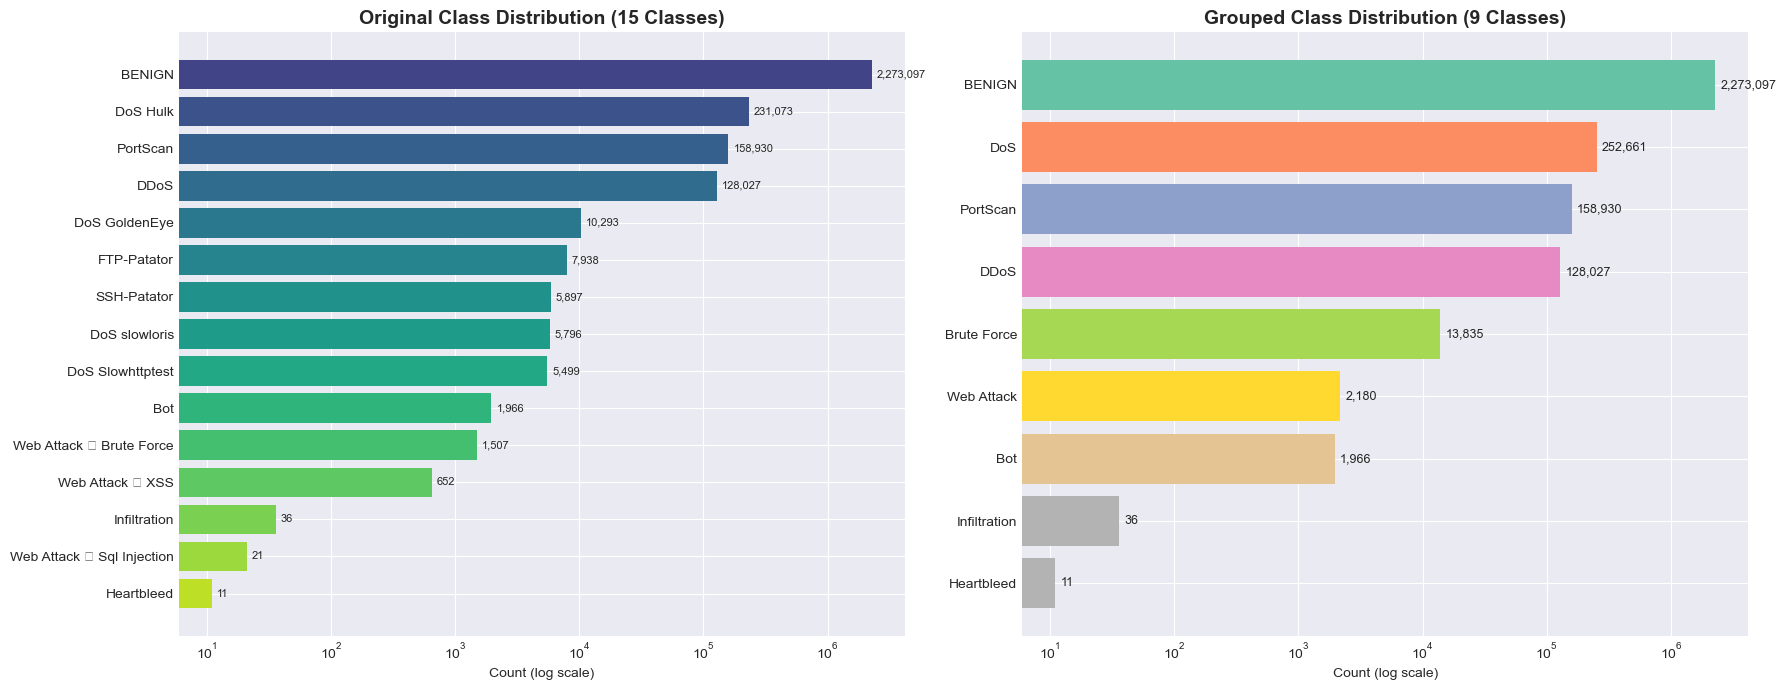

Saved: figures/class_distribution.png


In [6]:
# ============================================================
# 2.1 Class Distribution Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Original 15 classes
original_counts = df['Label'].value_counts()
colors_orig = plt.cm.viridis(np.linspace(0.2, 0.9, len(original_counts)))
bars1 = axes[0].barh(original_counts.index[::-1], original_counts.values[::-1], color=colors_orig[::-1])
axes[0].set_xscale('log')
axes[0].set_title('Original Class Distribution (15 Classes)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Count (log scale)')
for bar, count in zip(bars1, original_counts.values[::-1]):
    axes[0].text(bar.get_width() * 1.1, bar.get_y() + bar.get_height()/2, 
                f'{count:,}', va='center', fontsize=8)

# Grouped 9 classes
grouped_counts = df['Attack_Group'].value_counts()
colors_grp = plt.cm.Set2(np.linspace(0, 1, len(grouped_counts)))
bars2 = axes[1].barh(grouped_counts.index[::-1], grouped_counts.values[::-1], color=colors_grp[::-1])
axes[1].set_xscale('log')
axes[1].set_title('Grouped Class Distribution (9 Classes)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Count (log scale)')
for bar, count in zip(bars2, grouped_counts.values[::-1]):
    axes[1].text(bar.get_width() * 1.1, bar.get_y() + bar.get_height()/2, 
                f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/class_distribution.png")

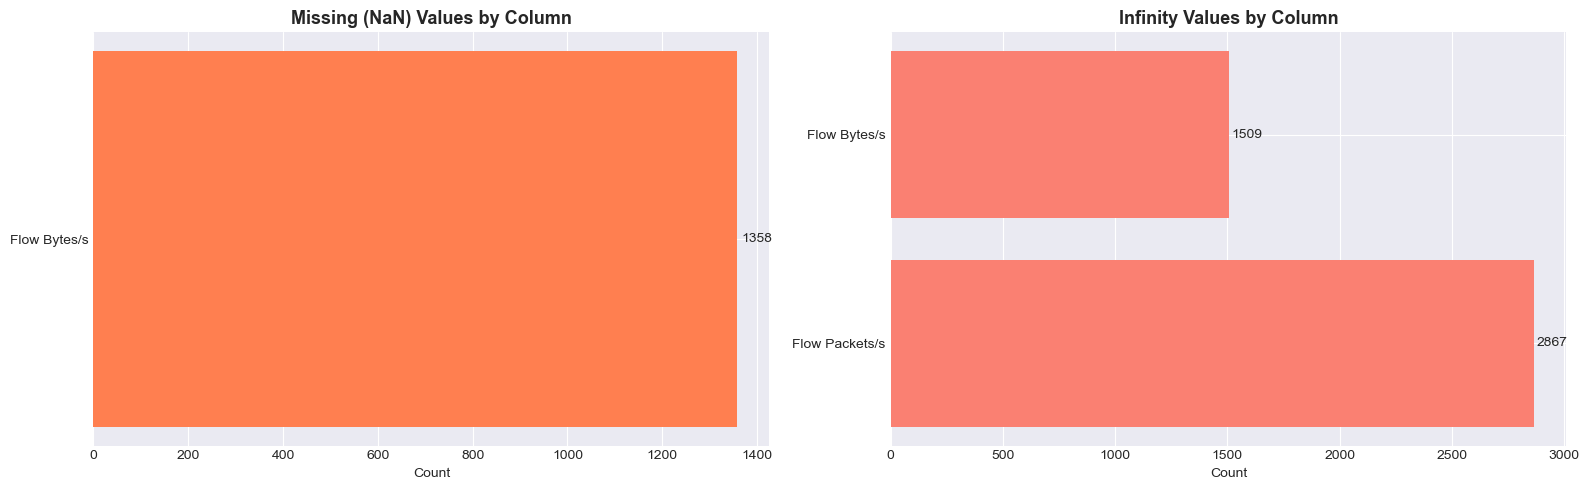

Saved: figures/missing_values.png


In [7]:
# ============================================================
# 2.2 Missing & Infinity Values Analysis
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Missing values
missing_vals = df.isnull().sum()
missing_vals = missing_vals[missing_vals > 0].sort_values(ascending=False)
if len(missing_vals) > 0:
    axes[0].barh(missing_vals.index, missing_vals.values, color='coral')
    axes[0].set_title('Missing (NaN) Values by Column', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Count')
    for i, v in enumerate(missing_vals.values):
        axes[0].text(v + 10, i, str(v), va='center')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', 
                fontsize=16, transform=axes[0].transAxes)
    axes[0].set_title('Missing (NaN) Values', fontsize=13, fontweight='bold')

# Infinity values
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_vals = np.isinf(df[numeric_cols]).sum()
inf_vals = inf_vals[inf_vals > 0].sort_values(ascending=False)
if len(inf_vals) > 0:
    axes[1].barh(inf_vals.index, inf_vals.values, color='salmon')
    axes[1].set_title('Infinity Values by Column', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Count')
    for i, v in enumerate(inf_vals.values):
        axes[1].text(v + 10, i, str(v), va='center')
else:
    axes[1].text(0.5, 0.5, 'No Infinity Values', ha='center', va='center',
                fontsize=16, transform=axes[1].transAxes)
    axes[1].set_title('Infinity Values', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/missing_values.png")

Top 15 Most Correlated Feature Pairs:
------------------------------------------------------------
  Fwd PSH Flags                  <-> SYN Flag Count                : 1.0000
  Fwd URG Flags                  <-> CWE Flag Count                : 1.0000
  RST Flag Count                 <-> ECE Flag Count                : 1.0000
  Fwd Packet Length Mean         <-> Avg Fwd Segment Size          : 1.0000
  Bwd Packet Length Mean         <-> Avg Bwd Segment Size          : 1.0000
  Fwd Header Length              <-> Fwd Header Length.1           : 1.0000
  Total Fwd Packets              <-> Subflow Fwd Packets           : 1.0000
  Total Length of Fwd Packets    <-> Subflow Fwd Bytes             : 1.0000
  Total Backward Packets         <-> Subflow Bwd Packets           : 1.0000
  Total Length of Bwd Packets    <-> Subflow Bwd Bytes             : 1.0000
  Total Fwd Packets              <-> Total Length of Bwd Packets   : 0.9997
  Total Length of Bwd Packets    <-> Subflow Fwd Packets         

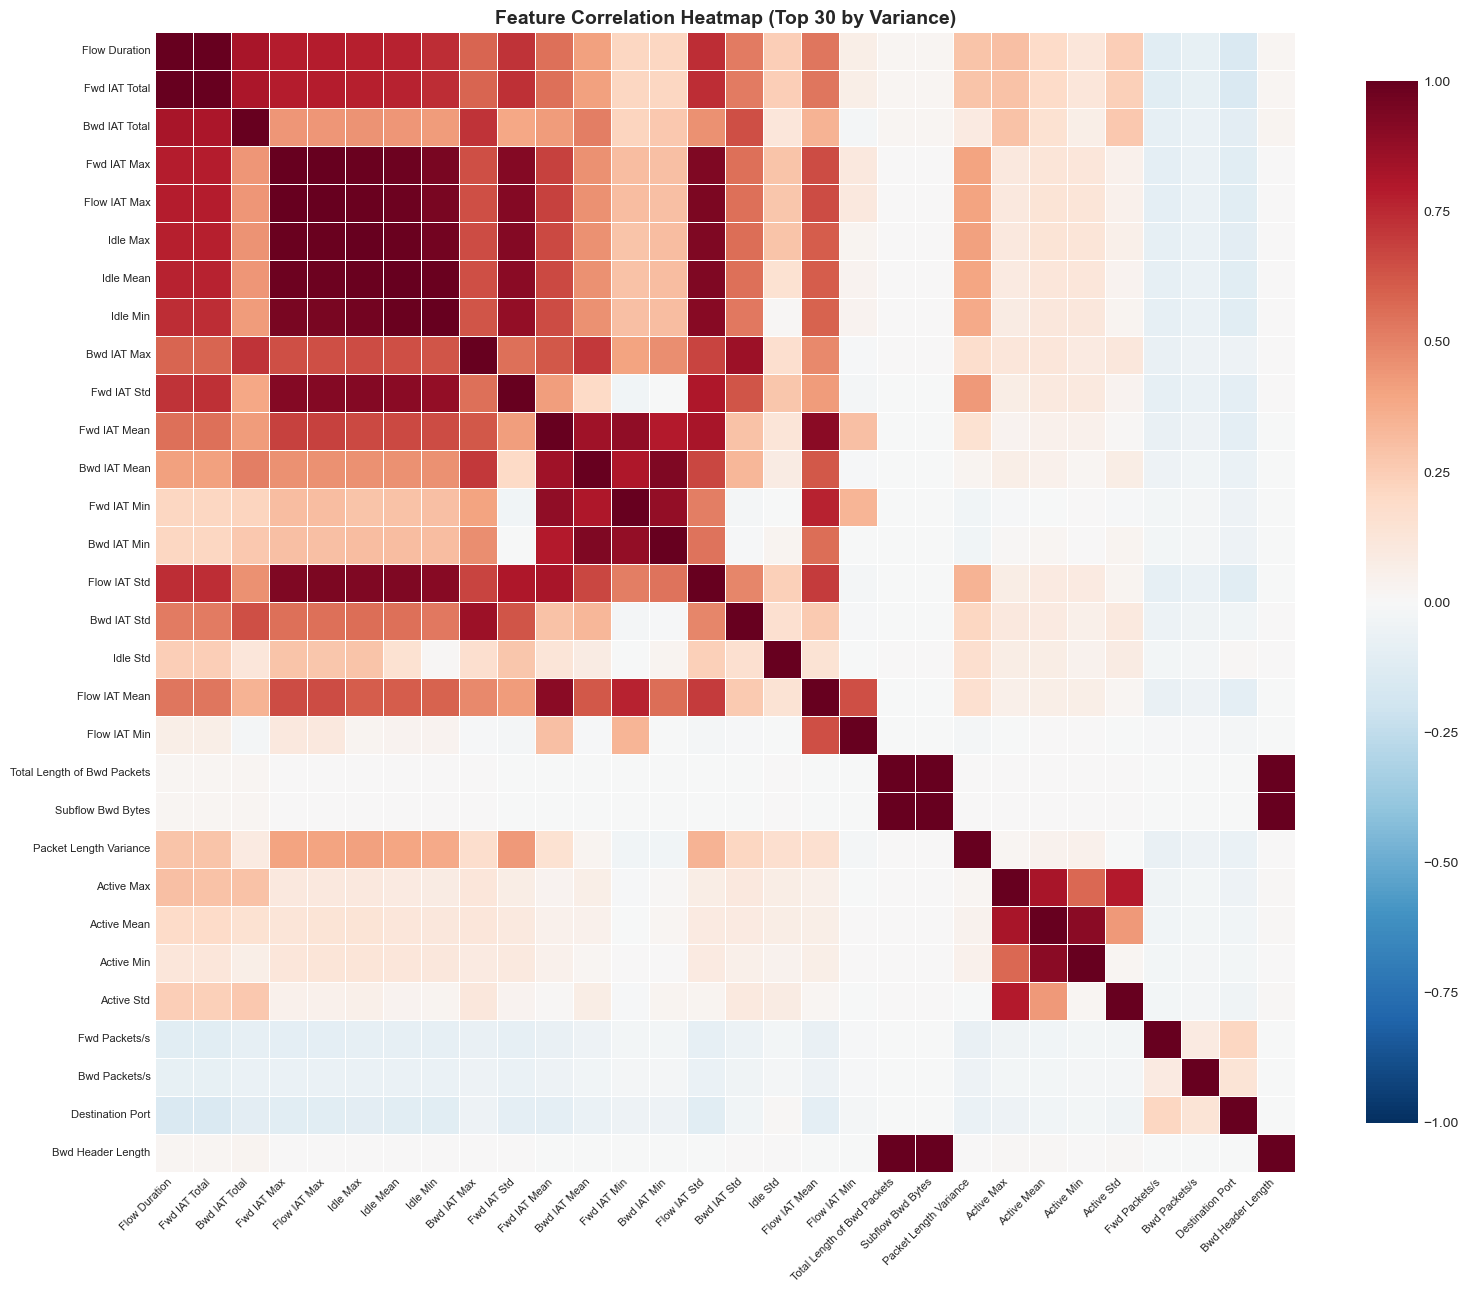

Saved: figures/correlation_heatmap.png


In [8]:
# ============================================================
# 2.3 Feature Correlation Heatmap (on 10% sample for speed)
# ============================================================
sample_df = df.sample(frac=0.1, random_state=RANDOM_STATE)
numeric_features = sample_df.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = sample_df[numeric_features].corr()

# Find top correlated pairs
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val):
            corr_pairs.append((idx, col, abs(val)))

corr_pairs.sort(key=lambda x: x[2], reverse=True)
print("Top 15 Most Correlated Feature Pairs:")
print("-" * 60)
for f1, f2, corr_val in corr_pairs[:15]:
    print(f"  {f1:30s} <-> {f2:30s}: {corr_val:.4f}")

# Plot heatmap of top 30 features by variance
top_var_features = sample_df[numeric_features].var().nlargest(30).index.tolist()
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(sample_df[top_var_features].corr(), 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, 
            cbar_kws={'shrink': 0.8},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title('Feature Correlation Heatmap (Top 30 by Variance)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/correlation_heatmap.png")

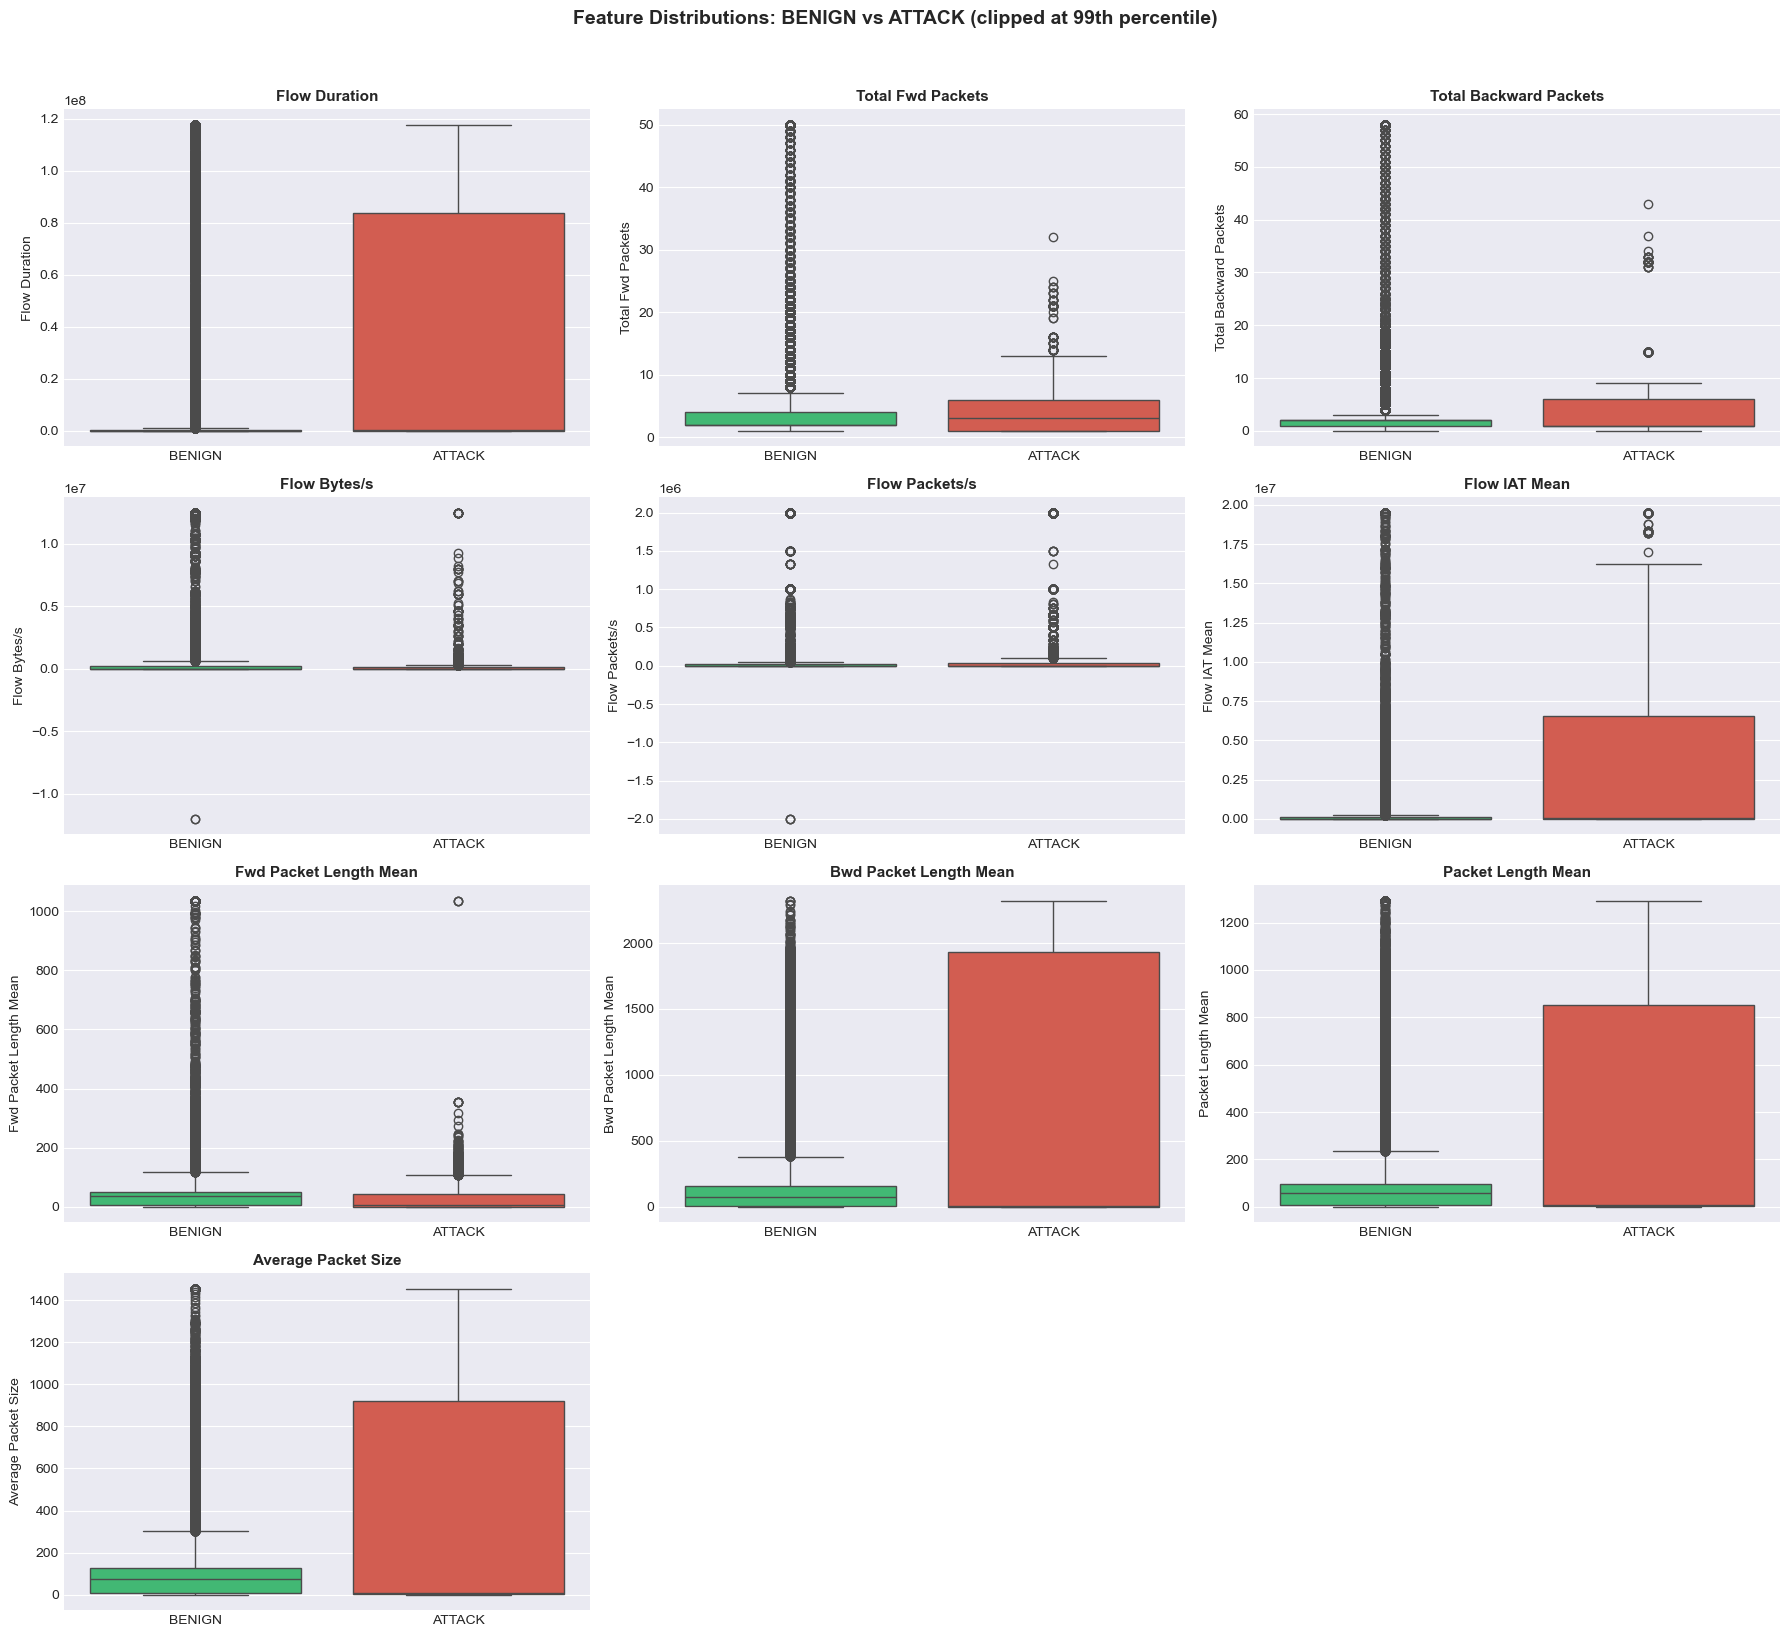

Saved: figures/feature_boxplots.png


In [9]:
# ============================================================
# 2.4 Key Feature Distributions (Benign vs Attack)
# ============================================================
key_features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean',
                'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
                'Packet Length Mean', 'Average Packet Size']

# Filter to features that exist in the dataset
key_features = [f for f in key_features if f in df.columns]

sample_for_box = df.sample(n=min(50000, len(df)), random_state=RANDOM_STATE).copy()
sample_for_box['Type'] = sample_for_box['Attack_Group'].apply(
    lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK'
)

n_feats = len(key_features)
n_cols = 3
n_rows = (n_feats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    data = sample_for_box[[feat, 'Type']].copy()
    data[feat] = pd.to_numeric(data[feat], errors='coerce')
    data = data.dropna()
    
    # Clip at 99th percentile for visualization
    upper = data[feat].quantile(0.99)
    data[feat] = data[feat].clip(upper=upper)
    
    sns.boxplot(data=data, x='Type', y=feat, ax=axes[i], 
                palette={'BENIGN': '#2ecc71', 'ATTACK': '#e74c3c'})
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: BENIGN vs ATTACK (clipped at 99th percentile)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/feature_boxplots.png")

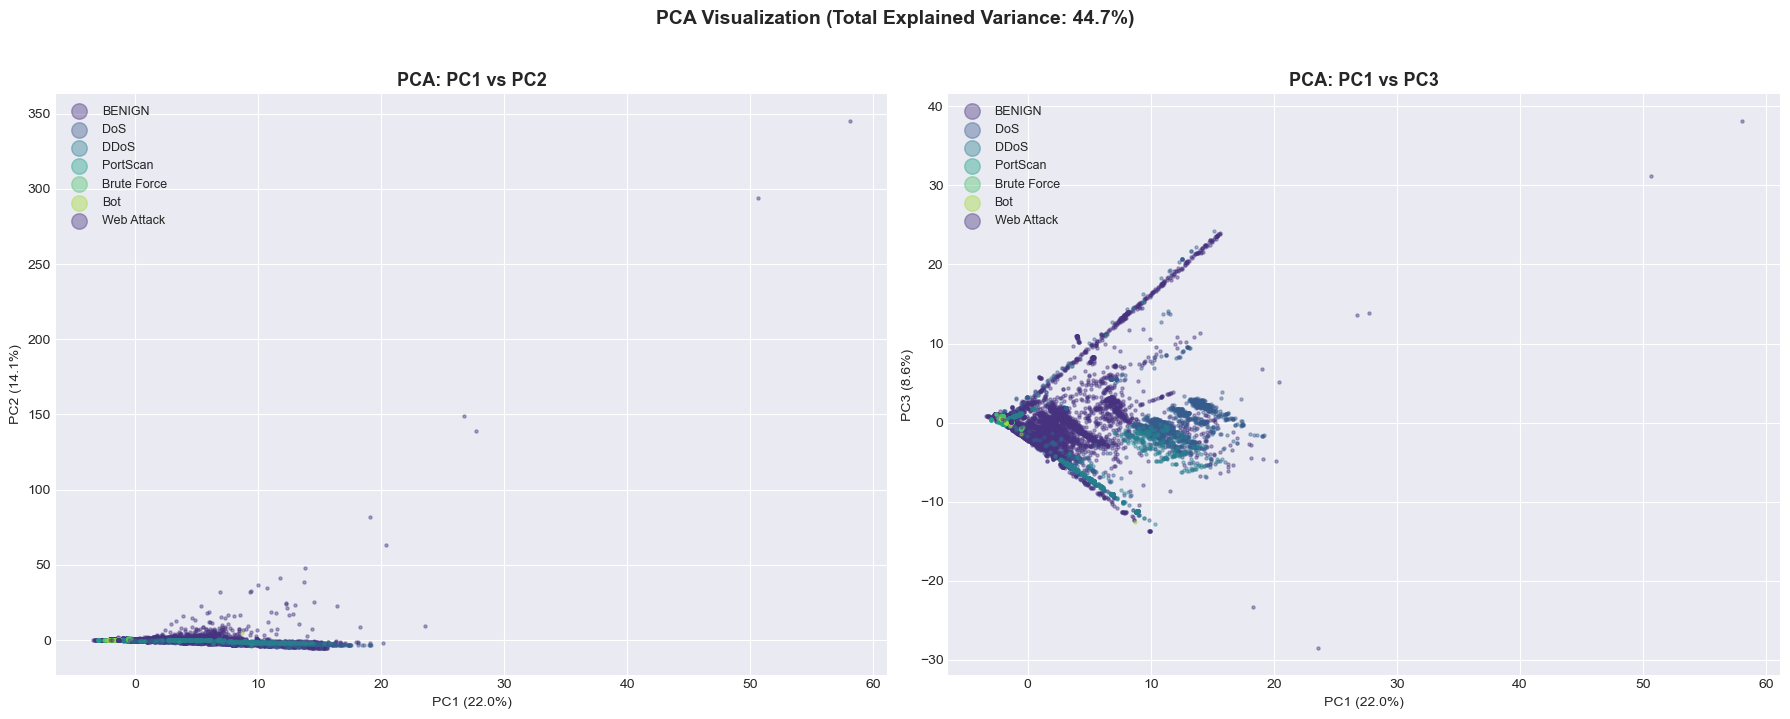

Saved: figures/pca_scatter.png


In [10]:
# ============================================================
# 2.5 PCA 2D Scatter Plot (colored by attack group)
# ============================================================
from sklearn.preprocessing import StandardScaler as SS

sample_pca = df.sample(n=min(30000, len(df)), random_state=RANDOM_STATE).copy()
numeric_cols_pca = sample_pca.select_dtypes(include=[np.number]).columns

# Clean data for PCA
X_pca = sample_pca[numeric_cols_pca].copy()
X_pca = X_pca.replace([np.inf, -np.inf], np.nan)
X_pca = X_pca.fillna(X_pca.median())

scaler_pca = SS()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca_transformed = pca.fit_transform(X_pca_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca_transformed[:, 0],
    'PC2': X_pca_transformed[:, 1],
    'PC3': X_pca_transformed[:, 2],
    'Attack_Group': sample_pca['Attack_Group'].values
})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PC1 vs PC2
for group in pca_df['Attack_Group'].unique():
    mask = pca_df['Attack_Group'] == group
    axes[0].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'], 
                   label=group, alpha=0.4, s=5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA: PC1 vs PC2', fontsize=13, fontweight='bold')
axes[0].legend(markerscale=5, fontsize=9)

# PC1 vs PC3
for group in pca_df['Attack_Group'].unique():
    mask = pca_df['Attack_Group'] == group
    axes[1].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC3'], 
                   label=group, alpha=0.4, s=5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
axes[1].set_title('PCA: PC1 vs PC3', fontsize=13, fontweight='bold')
axes[1].legend(markerscale=5, fontsize=9)

plt.suptitle(f'PCA Visualization (Total Explained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pca_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/pca_scatter.png")

In [11]:
# ============================================================
# 2.6 Statistical Summary
# ============================================================
print("=" * 60)
print("STATISTICAL SUMMARY OF NUMERIC FEATURES")
print("=" * 60)
desc = df.select_dtypes(include=[np.number]).describe().T
desc['missing'] = df.select_dtypes(include=[np.number]).isnull().sum()
desc['inf_count'] = np.isinf(df.select_dtypes(include=[np.number])).sum()
print(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing', 'inf_count']].to_string())

STATISTICAL SUMMARY OF NUMERIC FEATURES


                                 count          mean           std           min         25%           50%           75%           max  missing  inf_count
Destination Port             2830743.0  8.071483e+03  1.828363e+04  0.000000e+00   53.000000     80.000000  4.430000e+02  6.553500e+04        0          0
Flow Duration                2830743.0  1.478566e+07  3.365374e+07 -1.300000e+01  155.000000  31316.000000  3.204828e+06  1.200000e+08        0          0
Total Fwd Packets            2830743.0  9.361160e+00  7.496728e+02  1.000000e+00    2.000000      2.000000  5.000000e+00  2.197590e+05        0          0
Total Backward Packets       2830743.0  1.039377e+01  9.973883e+02  0.000000e+00    1.000000      2.000000  4.000000e+00  2.919220e+05        0          0
Total Length of Fwd Packets  2830743.0  5.493024e+02  9.993589e+03  0.000000e+00   12.000000     62.000000  1.870000e+02  1.290000e+07        0          0
Total Length of Bwd Packets  2830743.0  1.616264e+04  2.263088e+06  0.

<a id="3-preprocessing"></a>
## 3. Data Preprocessing & Feature Engineering

This section handles:
1. NaN and Infinity value treatment
2. Duplicate removal
3. Outlier clipping
4. Label encoding
5. Train-test split (80/20 stratified)
6. Feature selection (reduce dimensionality)
7. Feature scaling (StandardScaler)
8. Class imbalance handling (Undersample BENIGN + SMOTE minorities)

In [12]:
# ============================================================
# 3.1 Handle NaN and Infinity Values
# ============================================================
print("Before cleaning:")
print(f"  Shape: {df.shape}")
print(f"  NaN count: {df.isnull().sum().sum()}")

numeric_cols = df.select_dtypes(include=[np.number]).columns

# Replace infinity with NaN
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
print(f"  After replacing inf → NaN count: {df.isnull().sum().sum()}")

# Fill NaN with median (robust to outliers)
for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print(f"  After median imputation → NaN count: {df.isnull().sum().sum()}")

# Drop any remaining rows with NaN (in Label column etc.)
df = df.dropna()
print(f"\nAfter cleaning:")
print(f"  Shape: {df.shape}")

Before cleaning:
  Shape: (2830743, 80)


  NaN count: 1358


  After replacing inf → NaN count: 5734


  After median imputation → NaN count: 0



After cleaning:
  Shape: (2830743, 80)


In [13]:
# ============================================================
# 3.2 Remove Duplicates
# ============================================================
before_dedup = len(df)
df = df.drop_duplicates()
after_dedup = len(df)
print(f"Duplicate removal: {before_dedup:,} → {after_dedup:,} ({before_dedup - after_dedup:,} duplicates removed)")

Duplicate removal: 2,830,743 → 2,499,748 (330,995 duplicates removed)


In [14]:
# ============================================================
# 3.3 Clip Outliers at 1st and 99th Percentile
# ============================================================
numeric_cols = df.select_dtypes(include=[np.number]).columns

clipped_count = 0
for col in numeric_cols:
    q01 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    if q01 != q99:
        before = df[col].copy()
        df[col] = df[col].clip(lower=q01, upper=q99)
        clipped_count += (before != df[col]).sum()

print(f"Outlier clipping: {clipped_count:,} values clipped to [1st, 99th] percentile range")

Outlier clipping: 1,519,213 values clipped to [1st, 99th] percentile range


In [15]:
# ============================================================
# 3.4 Label Encoding & Train-Test Split
# ============================================================
# Use Attack_Group as target, drop original Label
target = df['Attack_Group']
feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()

X = df[feature_cols].copy()
y = target.copy()

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label Encoding Mapping:")
for i, cls in enumerate(le.classes_):
    count = (y_encoded == i).sum()
    print(f"  {i}: {cls:15s} ({count:,} samples)")

# Save label encoder
joblib.dump(le, os.path.join(MODELS_DIR, 'label_encoder.joblib'))
print(f"\nLabel encoder saved to models/label_encoder.joblib")

# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

print(f"\nTrain set: {X_train.shape[0]:,} samples")
print(f"Test set:  {X_test.shape[0]:,} samples")
print(f"Features:  {X_train.shape[1]}")

Label Encoding Mapping:
  0: BENIGN          (2,073,870 samples)
  1: Bot             (1,953 samples)
  2: Brute Force     (9,152 samples)
  3: DDoS            (128,016 samples)
  4: DoS             (193,748 samples)
  5: Heartbleed      (11 samples)
  6: Infiltration    (36 samples)
  7: PortScan        (90,819 samples)
  8: Web Attack      (2,143 samples)

Label encoder saved to models/label_encoder.joblib



Train set: 1,999,798 samples
Test set:  499,950 samples
Features:  78


Feature Selection Pipeline:
  Starting features: 78


  After removing zero-variance: 70 (removed 8)


  After removing high correlation (>0.95): 44 (removed 26)


  Computing Mutual Information on 50,000 samples...


  After Mutual Information selection: 35 features kept


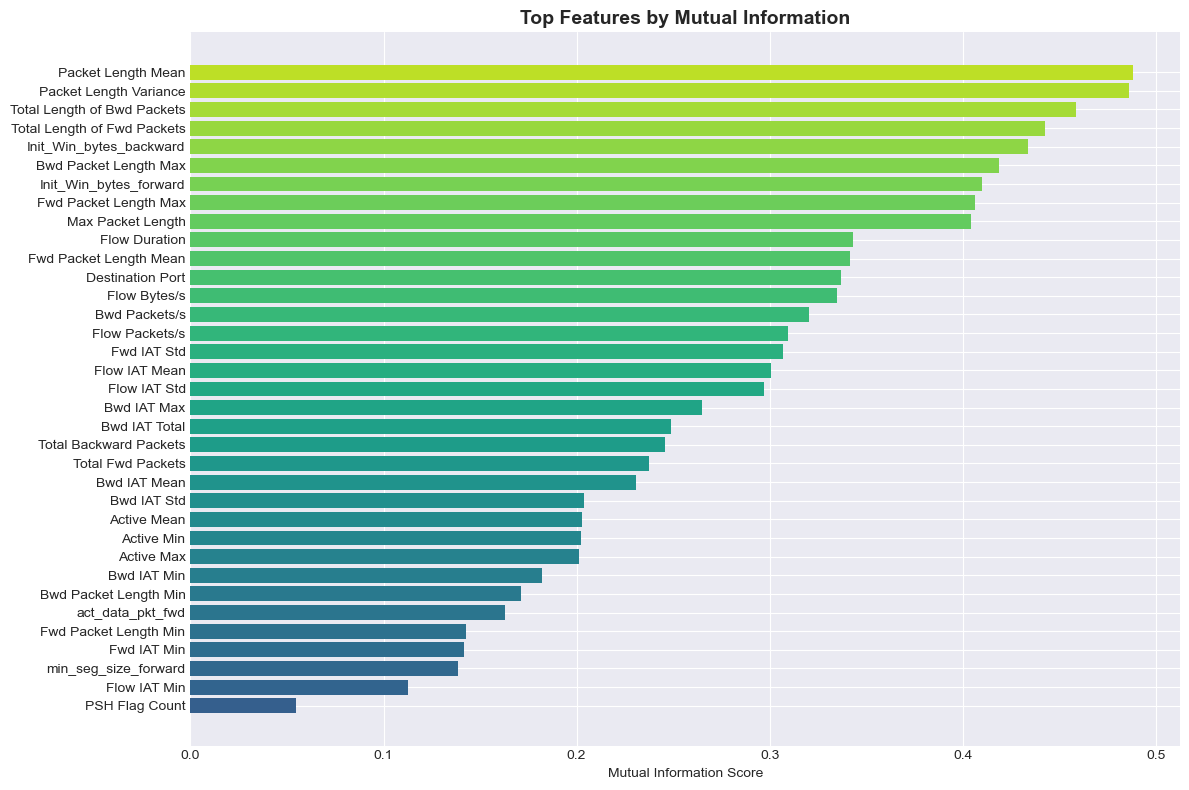

Saved: figures/feature_importance.png

Final feature set (35 features) saved to models/selected_features.joblib


In [16]:
# ============================================================
# 3.5 Feature Selection
# ============================================================
print("Feature Selection Pipeline:")
print(f"  Starting features: {X_train.shape[1]}")

# Step A: Remove zero-variance features
vt = VarianceThreshold(threshold=0.0)
vt.fit(X_train)
zero_var_mask = vt.get_support()
zero_var_removed = (~zero_var_mask).sum()
selected_features = [f for f, keep in zip(feature_cols, zero_var_mask) if keep]
print(f"  After removing zero-variance: {len(selected_features)} (removed {zero_var_removed})")

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

# Step B: Remove highly correlated features (correlation > 0.95)
corr_matrix = X_train_sel.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]
selected_features = [f for f in selected_features if f not in high_corr_cols]
print(f"  After removing high correlation (>0.95): {len(selected_features)} (removed {len(high_corr_cols)})")

X_train_sel = X_train_sel[selected_features]
X_test_sel = X_test_sel[selected_features]

# Step C: Mutual Information (on 10% sample for speed) - keep top features
sample_size = min(50000, len(X_train_sel))
sample_idx = np.random.choice(len(X_train_sel), sample_size, replace=False)
X_sample = X_train_sel.iloc[sample_idx]
y_sample = y_train[sample_idx]

print(f"  Computing Mutual Information on {sample_size:,} samples...")
mi_scores = mutual_info_classif(X_sample, y_sample, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': selected_features, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False)

# Keep top 35 features (or all if fewer)
n_keep = min(35, len(mi_df))
top_features = mi_df.head(n_keep)['Feature'].tolist()
print(f"  After Mutual Information selection: {len(top_features)} features kept")

# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 8))
mi_plot = mi_df.head(n_keep).sort_values('MI_Score')
ax.barh(mi_plot['Feature'], mi_plot['MI_Score'], color=plt.cm.viridis(np.linspace(0.3, 0.9, n_keep)))
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top Features by Mutual Information', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/feature_importance.png")

# Apply final feature selection
X_train_final = X_train[top_features]
X_test_final = X_test[top_features]

# Save selected features
joblib.dump(top_features, os.path.join(MODELS_DIR, 'selected_features.joblib'))
print(f"\nFinal feature set ({len(top_features)} features) saved to models/selected_features.joblib")

In [17]:
# ============================================================
# 3.6 Feature Scaling
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=top_features, index=X_train_final.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=top_features, index=X_test_final.index)

# Save scaler
joblib.dump(scaler, os.path.join(MODELS_DIR, 'scaler.joblib'))
print(f"StandardScaler fitted and saved to models/scaler.joblib")
print(f"Scaled train shape: {X_train_scaled.shape}")
print(f"Scaled test shape:  {X_test_scaled.shape}")

StandardScaler fitted and saved to models/scaler.joblib
Scaled train shape: (1999798, 35)
Scaled test shape:  (499950, 35)


In [18]:
# ============================================================
# 3.7 Handle Class Imbalance (Undersample BENIGN + SMOTE)
# ============================================================
print("Class distribution in training set BEFORE resampling:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]:15s}: {c:,}")

# Strategy: Undersample BENIGN to ~200K, SMOTE minority classes
# Find the BENIGN class index
benign_idx = list(le.classes_).index('BENIGN')

# Define undersampling strategy (only undersample BENIGN)
under_strategy = {benign_idx: 200000}

# Define SMOTE oversampling strategy (oversample minorities to at least 5000)
over_strategy = {}
for u, c in zip(unique, counts):
    if u != benign_idx and c < 5000:
        over_strategy[u] = max(5000, c * 5)  # At least 5x or 5000

# Determine k_neighbors based on smallest class
min_class_count = min(counts)
k_neighbors = min(5, min_class_count - 1)
k_neighbors = max(1, k_neighbors)
print(f"\nSMOTE k_neighbors set to: {k_neighbors} (smallest class has {min_class_count} samples)")

# Build resampling pipeline
resampling_pipeline = ImbPipeline([
    ('undersample', RandomUnderSampler(sampling_strategy=under_strategy, random_state=RANDOM_STATE)),
    ('smote', SMOTE(sampling_strategy=over_strategy, k_neighbors=k_neighbors, random_state=RANDOM_STATE))
])

print("\nResampling in progress (this may take a minute)...")
X_train_resampled, y_train_resampled = resampling_pipeline.fit_resample(X_train_scaled, y_train)

print(f"\nClass distribution AFTER resampling:")
unique_r, counts_r = np.unique(y_train_resampled, return_counts=True)
for u, c in zip(unique_r, counts_r):
    print(f"  {le.classes_[u]:15s}: {c:,}")
print(f"\nTotal training samples: {len(X_train_resampled):,} (was {len(X_train_scaled):,})")

Class distribution in training set BEFORE resampling:
  BENIGN         : 1,659,096
  Bot            : 1,562
  Brute Force    : 7,322
  DDoS           : 102,413
  DoS            : 154,998
  Heartbleed     : 9
  Infiltration   : 29
  PortScan       : 72,655
  Web Attack     : 1,714

SMOTE k_neighbors set to: 5 (smallest class has 9 samples)

Resampling in progress (this may take a minute)...



Class distribution AFTER resampling:
  BENIGN         : 200,000
  Bot            : 7,810
  Brute Force    : 7,322
  DDoS           : 102,413
  DoS            : 154,998
  Heartbleed     : 5,000
  Infiltration   : 5,000
  PortScan       : 72,655
  Web Attack     : 8,570

Total training samples: 563,768 (was 1,999,798)


<a id="4-ml-models"></a>
## 4. Traditional Machine Learning Models

We train and evaluate three traditional ML models:
1. **Decision Tree** (baseline)
2. **Random Forest** (ensemble)
3. **XGBoost** (gradient boosting)

In [19]:
# ============================================================
# 4.0 Helper Functions for Evaluation
# ============================================================
all_model_metrics = {}  # Store metrics for all models
all_confusion_matrices = {}
all_class_reports = {}

def evaluate_model(model, X_test, y_test, model_name, le):
    """Evaluate a model and return metrics, confusion matrix, and report."""
    start_time = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_time
    
    # Handle XGBoost predict output
    if hasattr(y_pred, 'values'):
        y_pred = y_pred.values
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision_macro': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'predict_time': predict_time
    }
    
    # ROC-AUC (needs predict_proba)
    try:
        y_prob = model.predict_proba(X_test)
        metrics['roc_auc'] = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    except Exception:
        metrics['roc_auc'] = None
    
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=le.classes_, 
                                   output_dict=True, zero_division=0)
    
    # Print results
    print(f"\n{'='*60}")
    print(f"  {model_name} - Evaluation Results")
    print(f"{'='*60}")
    print(f"  Accuracy:        {metrics['accuracy']:.4f}")
    print(f"  Precision (macro): {metrics['precision_macro']:.4f}")
    print(f"  Recall (macro):    {metrics['recall_macro']:.4f}")
    print(f"  F1-Score (macro):  {metrics['f1_macro']:.4f}")
    if metrics['roc_auc']:
        print(f"  ROC-AUC (macro):   {metrics['roc_auc']:.4f}")
    print(f"  Prediction time:   {predict_time:.2f}s")
    
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))
    
    return metrics, cm, report

def plot_confusion_matrix(cm, class_names, model_name):
    """Plot and save confusion matrix."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Normalize by row (recall per class)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized)
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=1)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'{model_name} - Normalized Confusion Matrix', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'confusion_matrix_{model_name.lower().replace(" ", "_")}.png'), 
                dpi=150, bbox_inches='tight')
    plt.show()

print("Evaluation helper functions defined.")

Evaluation helper functions defined.


Training Decision Tree...


Training completed in 22.7s



  Decision Tree - Evaluation Results
  Accuracy:        0.9966
  Precision (macro): 0.7859
  Recall (macro):    0.9829
  F1-Score (macro):  0.8484
  ROC-AUC (macro):   0.9916
  Prediction time:   0.19s

Classification Report:


              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    414774
         Bot       0.35      1.00      0.52       391
 Brute Force       0.95      1.00      0.97      1830
        DDoS       1.00      1.00      1.00     25603
         DoS       0.99      1.00      1.00     38750
  Heartbleed       0.40      1.00      0.57         2
Infiltration       0.75      0.86      0.80         7
    PortScan       0.98      1.00      0.99     18164
  Web Attack       0.65      1.00      0.78       429

    accuracy                           1.00    499950
   macro avg       0.79      0.98      0.85    499950
weighted avg       1.00      1.00      1.00    499950



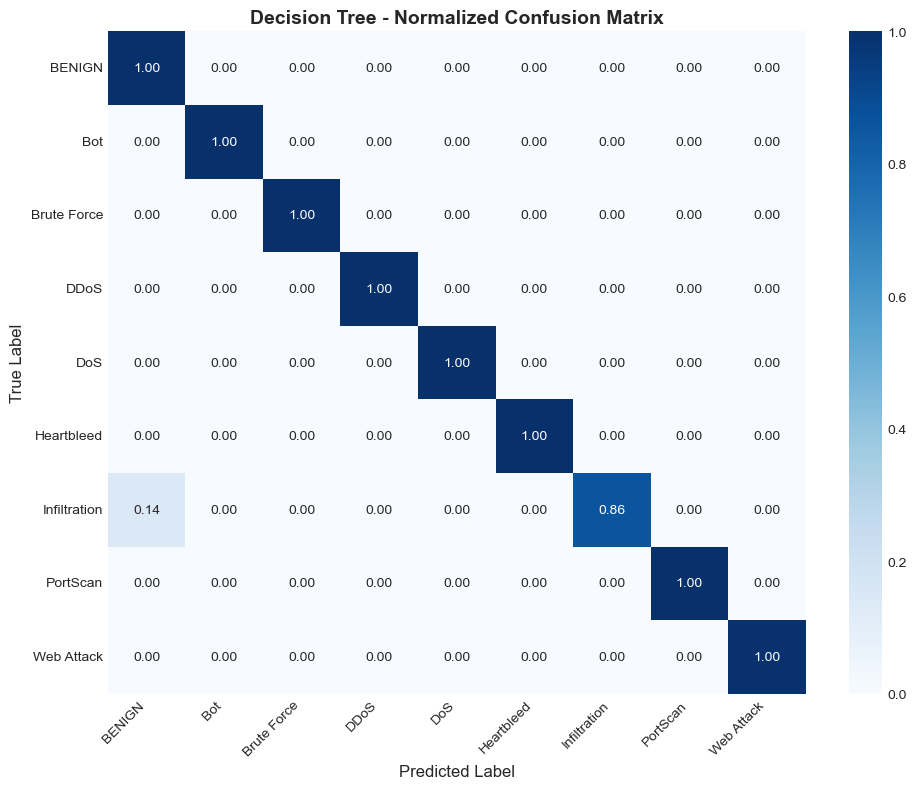

Model saved to models/decision_tree.joblib


In [20]:
# ============================================================
# 4.1 Model 1: Decision Tree
# ============================================================
print("Training Decision Tree...")
start = time.time()

dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dt_model.fit(X_train_resampled, y_train_resampled)
train_time_dt = time.time() - start
print(f"Training completed in {train_time_dt:.1f}s")

# Evaluate on TEST set (not resampled!)
dt_metrics, dt_cm, dt_report = evaluate_model(dt_model, X_test_scaled, y_test, 'Decision Tree', le)
dt_metrics['train_time'] = train_time_dt

# Plot confusion matrix
plot_confusion_matrix(dt_cm, le.classes_, 'Decision Tree')

# Save model
joblib.dump(dt_model, os.path.join(MODELS_DIR, 'decision_tree.joblib'))
print("Model saved to models/decision_tree.joblib")

# Store results
all_model_metrics['Decision Tree'] = dt_metrics
all_confusion_matrices['Decision Tree'] = dt_cm.tolist()
all_class_reports['Decision Tree'] = dt_report

Training Random Forest...


Training completed in 171.5s



  Random Forest - Evaluation Results
  Accuracy:        0.9978
  Precision (macro): 0.9251
  Recall (macro):    0.8789
  F1-Score (macro):  0.8657
  ROC-AUC (macro):   1.0000
  Prediction time:   6.39s

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    414774
         Bot       0.39      0.99      0.56       391
 Brute Force       1.00      1.00      1.00      1830
        DDoS       1.00      1.00      1.00     25603
         DoS       0.99      1.00      1.00     38750
  Heartbleed       1.00      0.50      0.67         2
Infiltration       1.00      0.43      0.60         7
    PortScan       0.99      1.00      0.99     18164
  Web Attack       0.95      1.00      0.97       429

    accuracy                           1.00    499950
   macro avg       0.93      0.88      0.87    499950
weighted avg       1.00      1.00      1.00    499950



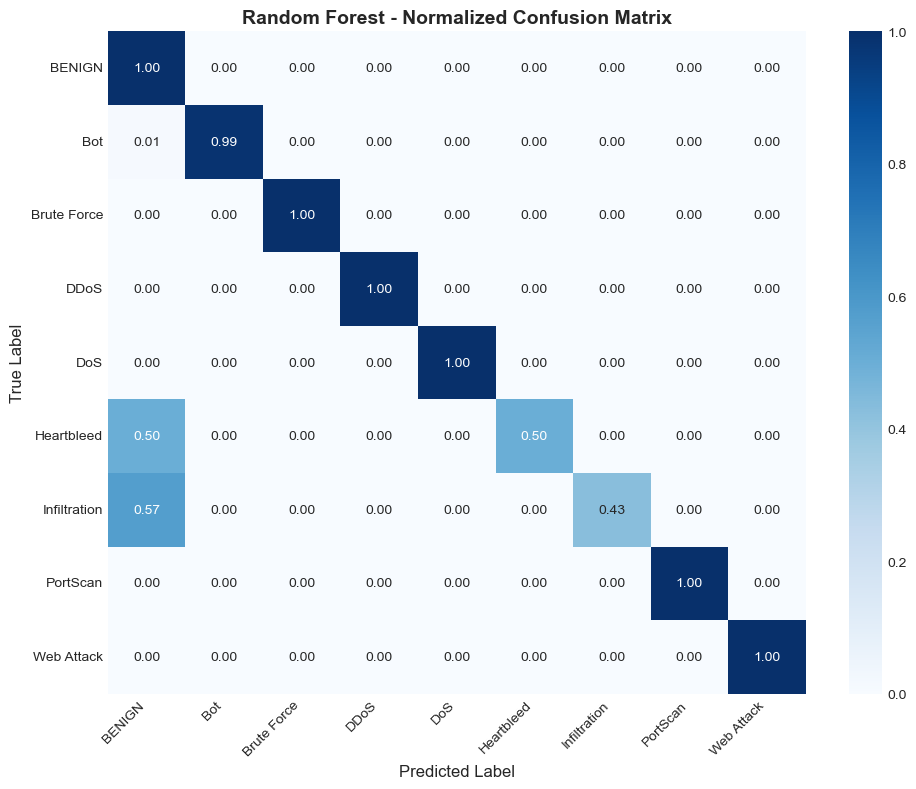

Model saved to models/random_forest.joblib


In [21]:
# ============================================================
# 4.2 Model 2: Random Forest
# ============================================================
print("Training Random Forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=10,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_model.fit(X_train_resampled, y_train_resampled)
train_time_rf = time.time() - start
print(f"Training completed in {train_time_rf:.1f}s")

# Evaluate
rf_metrics, rf_cm, rf_report = evaluate_model(rf_model, X_test_scaled, y_test, 'Random Forest', le)
rf_metrics['train_time'] = train_time_rf

# Plot confusion matrix
plot_confusion_matrix(rf_cm, le.classes_, 'Random Forest')

# Save model
joblib.dump(rf_model, os.path.join(MODELS_DIR, 'random_forest.joblib'))
print("Model saved to models/random_forest.joblib")

# Store results
all_model_metrics['Random Forest'] = rf_metrics
all_confusion_matrices['Random Forest'] = rf_cm.tolist()
all_class_reports['Random Forest'] = rf_report

Training XGBoost...


Training completed in 192.6s



  XGBoost - Evaluation Results
  Accuracy:        0.9988
  Precision (macro): 0.9553
  Recall (macro):    0.9660
  F1-Score (macro):  0.9541
  ROC-AUC (macro):   1.0000
  Prediction time:   12.44s

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    414774
         Bot       0.65      0.98      0.78       391
 Brute Force       1.00      1.00      1.00      1830
        DDoS       1.00      1.00      1.00     25603
         DoS       1.00      1.00      1.00     38750
  Heartbleed       1.00      1.00      1.00         2
Infiltration       1.00      0.71      0.83         7
    PortScan       0.99      1.00      0.99     18164
  Web Attack       0.97      1.00      0.98       429

    accuracy                           1.00    499950
   macro avg       0.96      0.97      0.95    499950
weighted avg       1.00      1.00      1.00    499950



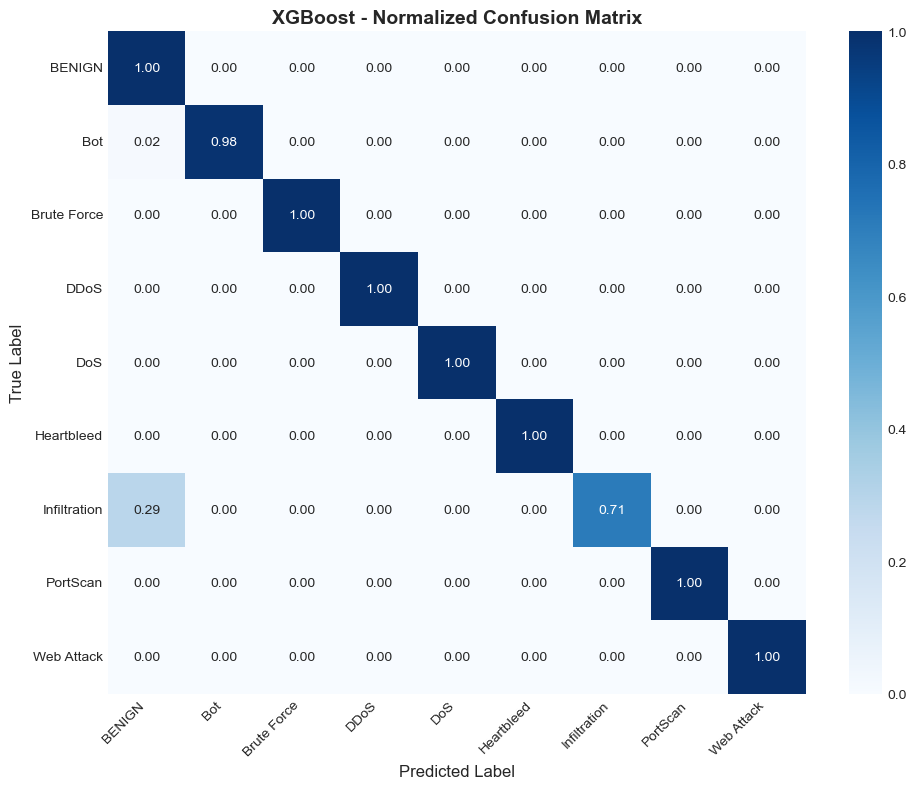

Model saved to models/xgboost_model.joblib


In [22]:
# ============================================================
# 4.3 Model 3: XGBoost
# ============================================================
print("Training XGBoost...")
start = time.time()

n_classes = len(le.classes_)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    objective='multi:softprob',
    num_class=n_classes,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_model.fit(X_train_resampled, y_train_resampled)
train_time_xgb = time.time() - start
print(f"Training completed in {train_time_xgb:.1f}s")

# Evaluate
xgb_metrics, xgb_cm, xgb_report = evaluate_model(xgb_model, X_test_scaled, y_test, 'XGBoost', le)
xgb_metrics['train_time'] = train_time_xgb

# Plot confusion matrix
plot_confusion_matrix(xgb_cm, le.classes_, 'XGBoost')

# Save model
joblib.dump(xgb_model, os.path.join(MODELS_DIR, 'xgboost_model.joblib'))
print("Model saved to models/xgboost_model.joblib")

# Store results
all_model_metrics['XGBoost'] = xgb_metrics
all_confusion_matrices['XGBoost'] = xgb_cm.tolist()
all_class_reports['XGBoost'] = xgb_report

In [23]:
# ============================================================
# 4.4 Cross-Validation (5-Fold Stratified) for Traditional Models
# ============================================================
print("Running 5-Fold Stratified Cross-Validation...")
print("(This may take several minutes)\n")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
}

cv_models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=20, min_samples_split=20, 
                                            min_samples_leaf=10, class_weight='balanced',
                                            random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=25, 
                                            class_weight='balanced', n_jobs=-1,
                                            random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.1,
                             tree_method='hist', use_label_encoder=False,
                             eval_metric='mlogloss', n_jobs=-1, verbosity=0,
                             random_state=RANDOM_STATE),
}

cv_results_all = {}
for name, model in cv_models.items():
    print(f"  Cross-validating {name}...")
    start = time.time()
    cv_result = cross_validate(model, X_train_resampled, y_train_resampled, 
                               cv=skf, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - start
    
    cv_results_all[name] = {
        metric: f"{cv_result[f'test_{metric}'].mean():.4f} (+/- {cv_result[f'test_{metric}'].std():.4f})"
        for metric in scoring
    }
    print(f"    Done in {elapsed:.1f}s")
    for metric in scoring:
        vals = cv_result[f'test_{metric}']
        print(f"    {metric:20s}: {vals.mean():.4f} (+/- {vals.std():.4f})")
    print()

# Store CV results in model metrics
for name in cv_results_all:
    all_model_metrics[name]['cv_results'] = cv_results_all[name]

print("Cross-validation complete!")

Running 5-Fold Stratified Cross-Validation...
(This may take several minutes)

  Cross-validating Decision Tree...


    Done in 39.9s
    accuracy            : 0.9978 (+/- 0.0002)
    precision_macro     : 0.9901 (+/- 0.0008)
    recall_macro        : 0.9987 (+/- 0.0002)
    f1_macro            : 0.9943 (+/- 0.0005)

  Cross-validating Random Forest...


    Done in 320.0s
    accuracy            : 0.9986 (+/- 0.0001)
    precision_macro     : 0.9958 (+/- 0.0006)
    recall_macro        : 0.9984 (+/- 0.0003)
    f1_macro            : 0.9971 (+/- 0.0004)

  Cross-validating XGBoost...


    Done in 144.1s
    accuracy            : 0.9992 (+/- 0.0000)
    precision_macro     : 0.9977 (+/- 0.0003)
    recall_macro        : 0.9989 (+/- 0.0002)
    f1_macro            : 0.9983 (+/- 0.0002)

Cross-validation complete!


<a id="5-dl-models"></a>
## 5. Deep Learning Models

We train two neural network architectures:
1. **Deep Neural Network (DNN)** - Multi-layer feedforward network with dropout
2. **1D-CNN** - Convolutional neural network treating features as a 1D signal

In [24]:
# ============================================================
# 5.0 Prepare Data for Deep Learning
# ============================================================
# Convert to numpy arrays
X_train_dl = np.array(X_train_resampled, dtype=np.float32)
X_test_dl = np.array(X_test_scaled, dtype=np.float32)
y_train_dl = np.array(y_train_resampled, dtype=np.int32)
y_test_dl = np.array(y_test, dtype=np.int32)

n_features = X_train_dl.shape[1]
n_classes = len(le.classes_)

# Compute class weights for DL models
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train_dl), y=y_train_dl)
class_weight_dict = dict(zip(np.unique(y_train_dl), class_weights_arr))

print(f"DL Data shapes:")
print(f"  X_train: {X_train_dl.shape}, X_test: {X_test_dl.shape}")
print(f"  y_train: {y_train_dl.shape}, y_test: {y_test_dl.shape}")
print(f"  Features: {n_features}, Classes: {n_classes}")
print(f"  Class weights: {dict((le.classes_[k], f'{v:.2f}') for k, v in class_weight_dict.items())}")

DL Data shapes:
  X_train: (563768, 35), X_test: (499950, 35)
  y_train: (563768,), y_test: (499950,)
  Features: 35, Classes: 9
  Class weights: {'BENIGN': '0.31', 'Bot': '8.02', 'Brute Force': '8.56', 'DDoS': '0.61', 'DoS': '0.40', 'Heartbleed': '12.53', 'Infiltration': '12.53', 'PortScan': '0.86', 'Web Attack': '7.31'}


In [25]:
# ============================================================
# 5.1 Model 4: Deep Neural Network (DNN)
# ============================================================
print("Building DNN model...")

dnn_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(n_classes, activation='softmax')
])

dnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dnn_model.summary()

# Callbacks
dnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Train
print("\nTraining DNN...")
start = time.time()
dnn_history = dnn_model.fit(
    X_train_dl, y_train_dl,
    validation_split=0.15,
    epochs=50,
    batch_size=1024,
    class_weight=class_weight_dict,
    callbacks=dnn_callbacks,
    verbose=1
)
train_time_dnn = time.time() - start
print(f"\nDNN training completed in {train_time_dnn:.1f}s")

Building DNN model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,745 (206.04 KB)

 Trainable params: 51,849 (202.54 KB)

...

450/468 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9812 - loss: 0.0253

457/468 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9812 - loss: 0.0252

465/468 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9812 - loss: 0.0252

468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9814 - loss: 0.0244 - val_accuracy: 0.8897 - val_loss: 0.9384 - learning_rate: 5.0000e-04



DNN training completed in 31.9s


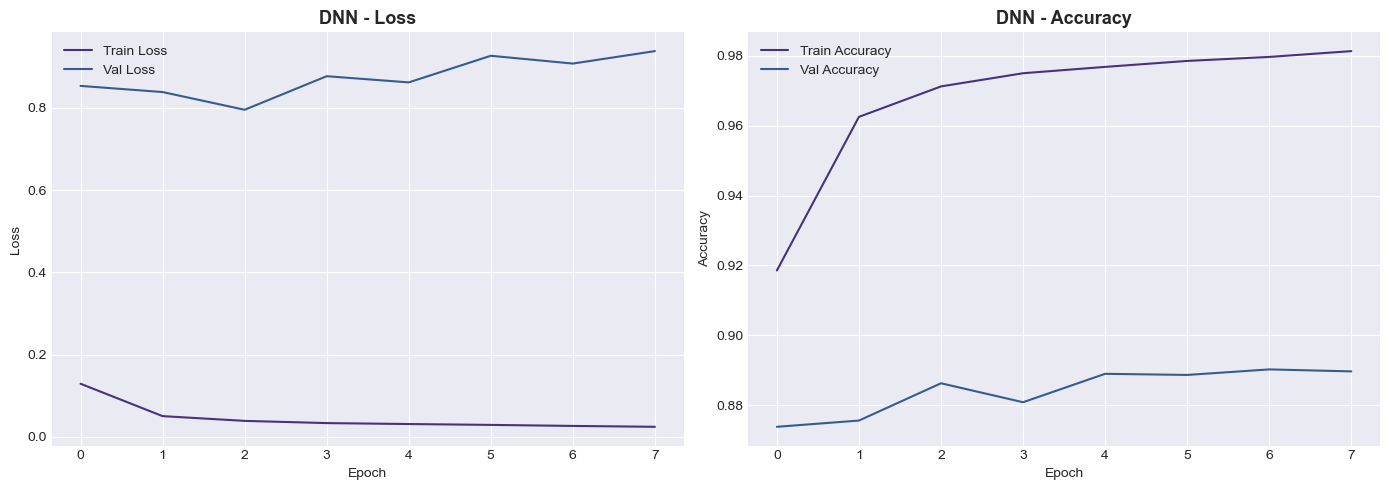

Saved: figures/training_history_dnn.png



  DNN - Evaluation Results
  accuracy            : 0.9531
  precision_macro     : 0.5771
  recall_macro        : 0.8471
  f1_macro            : 0.5987
  train_time          : 31.9287
  roc_auc             : 0.9928

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.95      0.97    414774
         Bot       0.03      0.98      0.05       391
 Brute Force       0.25      1.00      0.40      1830
        DDoS       0.99      1.00      0.99     25603
         DoS       0.94      0.99      0.96     38750
  Heartbleed       1.00      1.00      1.00         2
Infiltration       0.01      0.71      0.02         7
    PortScan       0.97      1.00      0.98     18164
  Web Attack       0.00      0.00      0.00       429

    accuracy                           0.95    499950
   macro avg       0.58      0.85      0.60    499950
weighted avg       0.99      0.95      0.97    499950



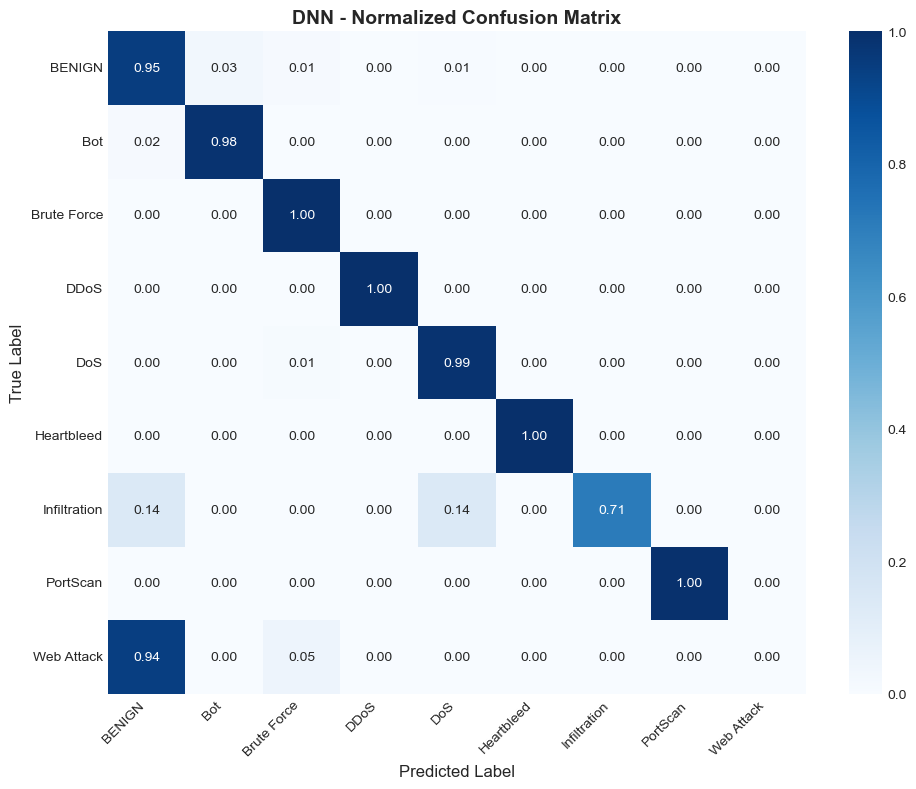

Model saved to models/dnn_model.keras


In [26]:
# ============================================================
# 5.1b DNN Training History & Evaluation
# ============================================================
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(dnn_history.history['loss'], label='Train Loss')
axes[0].plot(dnn_history.history['val_loss'], label='Val Loss')
axes[0].set_title('DNN - Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(dnn_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(dnn_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('DNN - Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'training_history_dnn.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/training_history_dnn.png")

# Evaluate DNN
y_pred_dnn = np.argmax(dnn_model.predict(X_test_dl, verbose=0), axis=1)
y_prob_dnn = dnn_model.predict(X_test_dl, verbose=0)

dnn_metrics = {
    'accuracy': accuracy_score(y_test_dl, y_pred_dnn),
    'precision_macro': precision_score(y_test_dl, y_pred_dnn, average='macro', zero_division=0),
    'recall_macro': recall_score(y_test_dl, y_pred_dnn, average='macro', zero_division=0),
    'f1_macro': f1_score(y_test_dl, y_pred_dnn, average='macro', zero_division=0),
    'train_time': train_time_dnn,
}

try:
    dnn_metrics['roc_auc'] = roc_auc_score(y_test_dl, y_prob_dnn, multi_class='ovr', average='macro')
except Exception:
    dnn_metrics['roc_auc'] = None

print(f"\n{'='*60}")
print(f"  DNN - Evaluation Results")
print(f"{'='*60}")
for k, v in dnn_metrics.items():
    if v is not None:
        print(f"  {k:20s}: {v:.4f}" if isinstance(v, float) else f"  {k:20s}: {v}")

print(f"\nClassification Report:")
print(classification_report(y_test_dl, y_pred_dnn, target_names=le.classes_, zero_division=0))

dnn_cm = confusion_matrix(y_test_dl, y_pred_dnn)
dnn_report = classification_report(y_test_dl, y_pred_dnn, target_names=le.classes_, 
                                    output_dict=True, zero_division=0)
plot_confusion_matrix(dnn_cm, le.classes_, 'DNN')

# Save model
dnn_model.save(os.path.join(MODELS_DIR, 'dnn_model.keras'))
print("Model saved to models/dnn_model.keras")

# Store results
all_model_metrics['DNN'] = dnn_metrics
all_confusion_matrices['DNN'] = dnn_cm.tolist()
all_class_reports['DNN'] = dnn_report

In [27]:
# ============================================================
# 5.2 Model 5: 1D-CNN
# ============================================================
print("Building 1D-CNN model...")

# Reshape input for CNN: (samples, features, 1)
X_train_cnn = X_train_dl.reshape(-1, n_features, 1)
X_test_cnn = X_test_dl.reshape(-1, n_features, 1)

cnn_model = keras.Sequential([
    layers.Input(shape=(n_features, 1)),
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# Callbacks
cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Train
print("\nTraining 1D-CNN...")
start = time.time()
cnn_history = cnn_model.fit(
    X_train_cnn, y_train_dl,
    validation_split=0.15,
    epochs=50,
    batch_size=1024,
    class_weight=class_weight_dict,
    callbacks=cnn_callbacks,
    verbose=1
)
train_time_cnn = time.time() - start
print(f"\n1D-CNN training completed in {train_time_cnn:.1f}s")

Building 1D-CNN model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 35, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 35, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 35, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 35, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 17, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 17, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 17, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,369 (216.29 KB)

 Trainable params: 54,857 (214.29 KB)

...

466/468 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9902 - loss: 0.0125

467/468 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9902 - loss: 0.0125

468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9902 - loss: 0.0125

468/468 ━━━━━━━━━━━━━━━━━━━━ 54s 115ms/step - accuracy: 0.9904 - loss: 0.0117 - val_accuracy: 0.8897 - val_loss: 1.3496 - learning_rate: 5.0000e-04



1D-CNN training completed in 875.0s


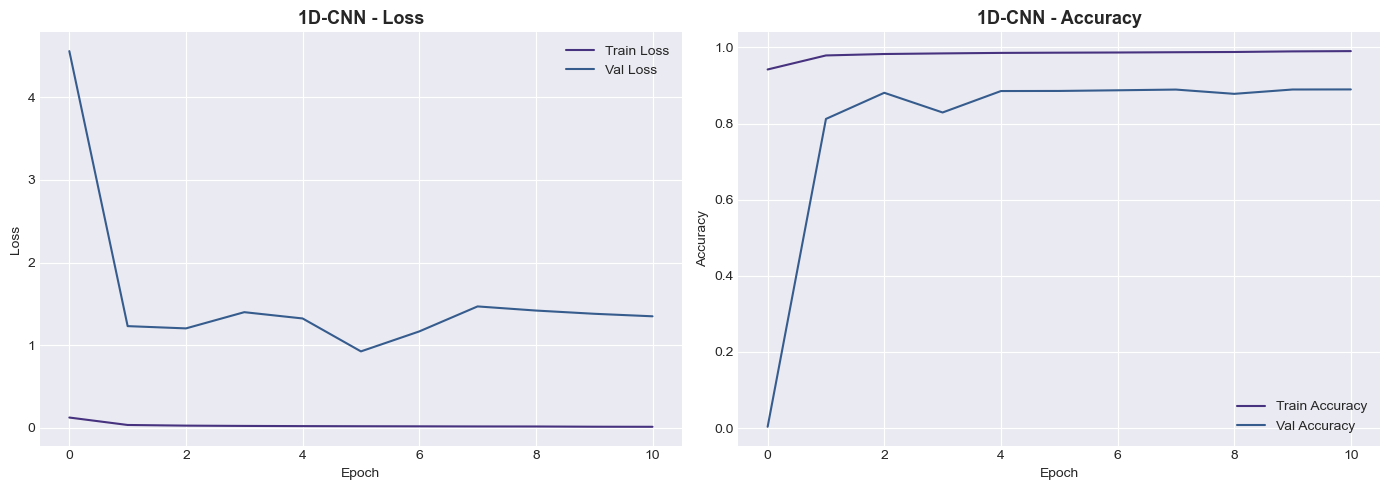

Saved: figures/training_history_cnn.png



  1D-CNN - Evaluation Results
  accuracy            : 0.9678
  precision_macro     : 0.5830
  recall_macro        : 0.8430
  f1_macro            : 0.6061
  train_time          : 874.9961
  roc_auc             : 0.9827

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      0.97      0.98    414774
         Bot       0.06      0.96      0.12       391
 Brute Force       0.21      1.00      0.34      1830
        DDoS       1.00      1.00      1.00     25603
         DoS       0.98      0.95      0.97     38750
  Heartbleed       1.00      1.00      1.00         2
Infiltration       0.03      0.71      0.07         7
    PortScan       0.97      1.00      0.98     18164
  Web Attack       0.00      0.00      0.00       429

    accuracy                           0.97    499950
   macro avg       0.58      0.84      0.61    499950
weighted avg       0.99      0.97      0.98    499950



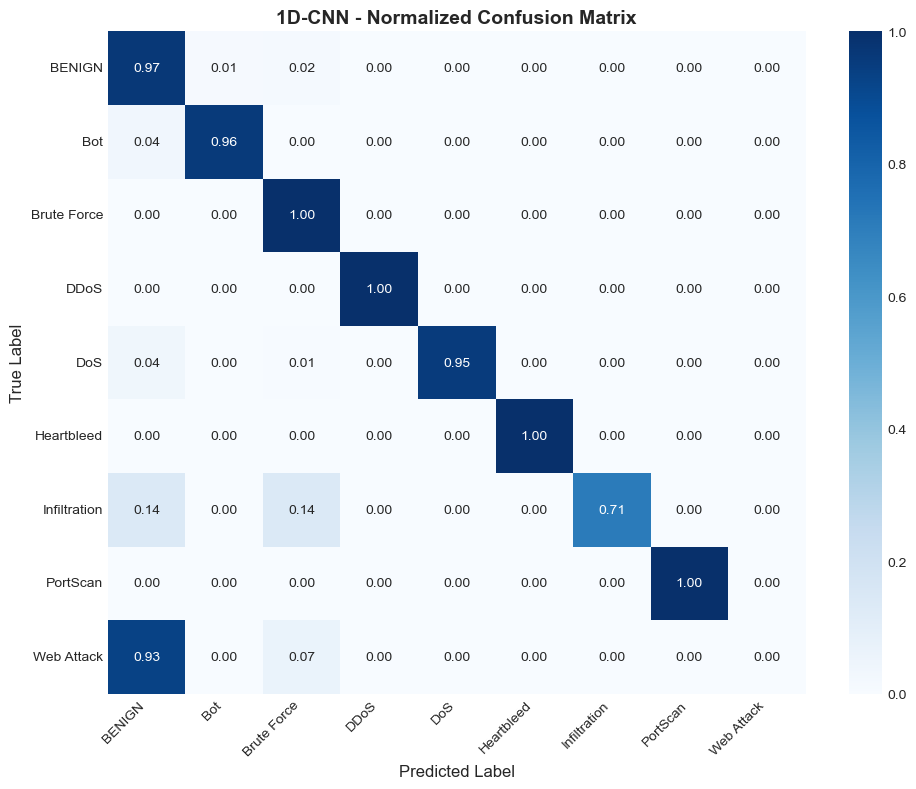

Model saved to models/cnn_model.keras


In [28]:
# ============================================================
# 5.2b 1D-CNN Training History & Evaluation
# ============================================================
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history['loss'], label='Train Loss')
axes[0].plot(cnn_history.history['val_loss'], label='Val Loss')
axes[0].set_title('1D-CNN - Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(cnn_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(cnn_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('1D-CNN - Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'training_history_cnn.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/training_history_cnn.png")

# Evaluate 1D-CNN
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn, verbose=0), axis=1)
y_prob_cnn = cnn_model.predict(X_test_cnn, verbose=0)

cnn_metrics = {
    'accuracy': accuracy_score(y_test_dl, y_pred_cnn),
    'precision_macro': precision_score(y_test_dl, y_pred_cnn, average='macro', zero_division=0),
    'recall_macro': recall_score(y_test_dl, y_pred_cnn, average='macro', zero_division=0),
    'f1_macro': f1_score(y_test_dl, y_pred_cnn, average='macro', zero_division=0),
    'train_time': train_time_cnn,
}

try:
    cnn_metrics['roc_auc'] = roc_auc_score(y_test_dl, y_prob_cnn, multi_class='ovr', average='macro')
except Exception:
    cnn_metrics['roc_auc'] = None

print(f"\n{'='*60}")
print(f"  1D-CNN - Evaluation Results")
print(f"{'='*60}")
for k, v in cnn_metrics.items():
    if v is not None:
        print(f"  {k:20s}: {v:.4f}" if isinstance(v, float) else f"  {k:20s}: {v}")

print(f"\nClassification Report:")
print(classification_report(y_test_dl, y_pred_cnn, target_names=le.classes_, zero_division=0))

cnn_cm = confusion_matrix(y_test_dl, y_pred_cnn)
cnn_report = classification_report(y_test_dl, y_pred_cnn, target_names=le.classes_, 
                                    output_dict=True, zero_division=0)
plot_confusion_matrix(cnn_cm, le.classes_, '1D-CNN')

# Save model
cnn_model.save(os.path.join(MODELS_DIR, 'cnn_model.keras'))
print("Model saved to models/cnn_model.keras")

# Store results
all_model_metrics['1D-CNN'] = cnn_metrics
all_confusion_matrices['1D-CNN'] = cnn_cm.tolist()
all_class_reports['1D-CNN'] = cnn_report

<a id="6-comparison"></a>
## 6. Model Comparison & Results

Comprehensive comparison of all 5 models across all evaluation metrics.

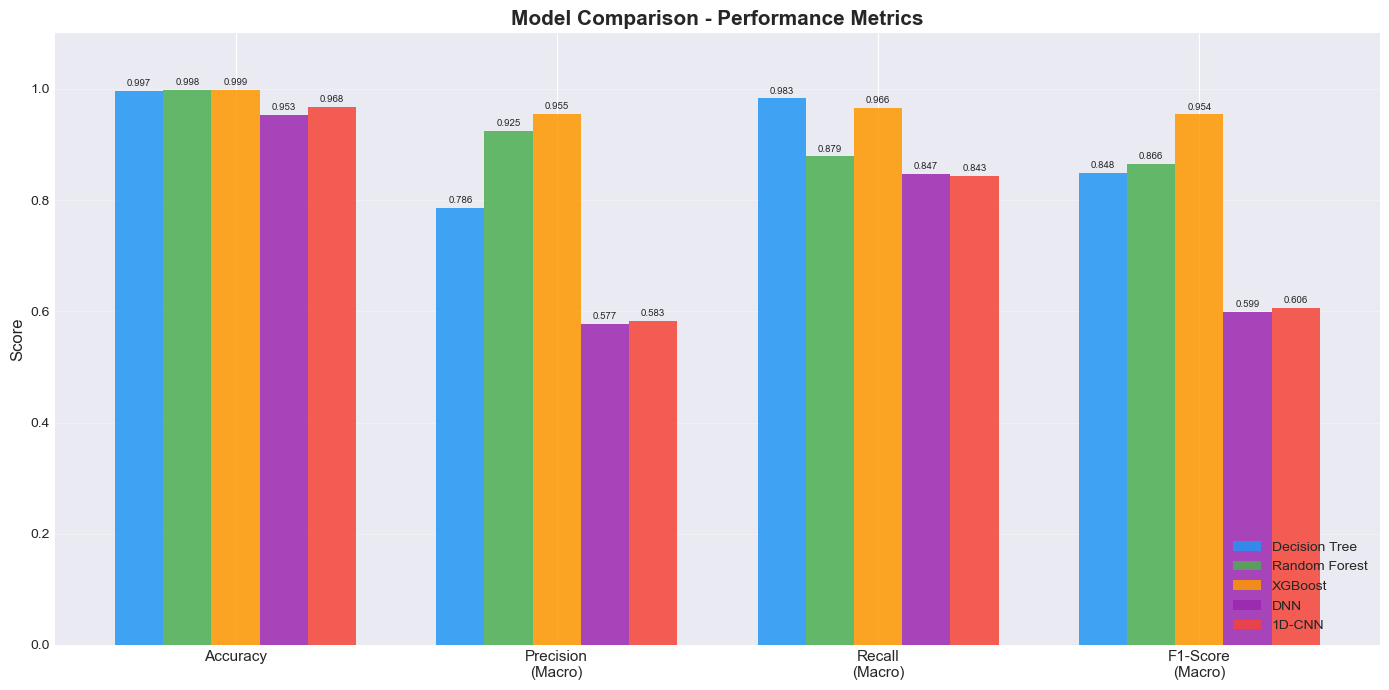

Saved: figures/model_comparison_bar.png


In [29]:
# ============================================================
# 6.1 Model Comparison Bar Chart
# ============================================================
model_names = list(all_model_metrics.keys())
metrics_to_compare = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
metric_labels = ['Accuracy', 'Precision\n(Macro)', 'Recall\n(Macro)', 'F1-Score\n(Macro)']

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(metrics_to_compare))
width = 0.15
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    values = [all_model_metrics[model_name].get(m, 0) or 0 for m in metrics_to_compare]
    bars = ax.bar(x + i * width, values, width, label=model_name, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=0)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison - Performance Metrics', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'model_comparison_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/model_comparison_bar.png")

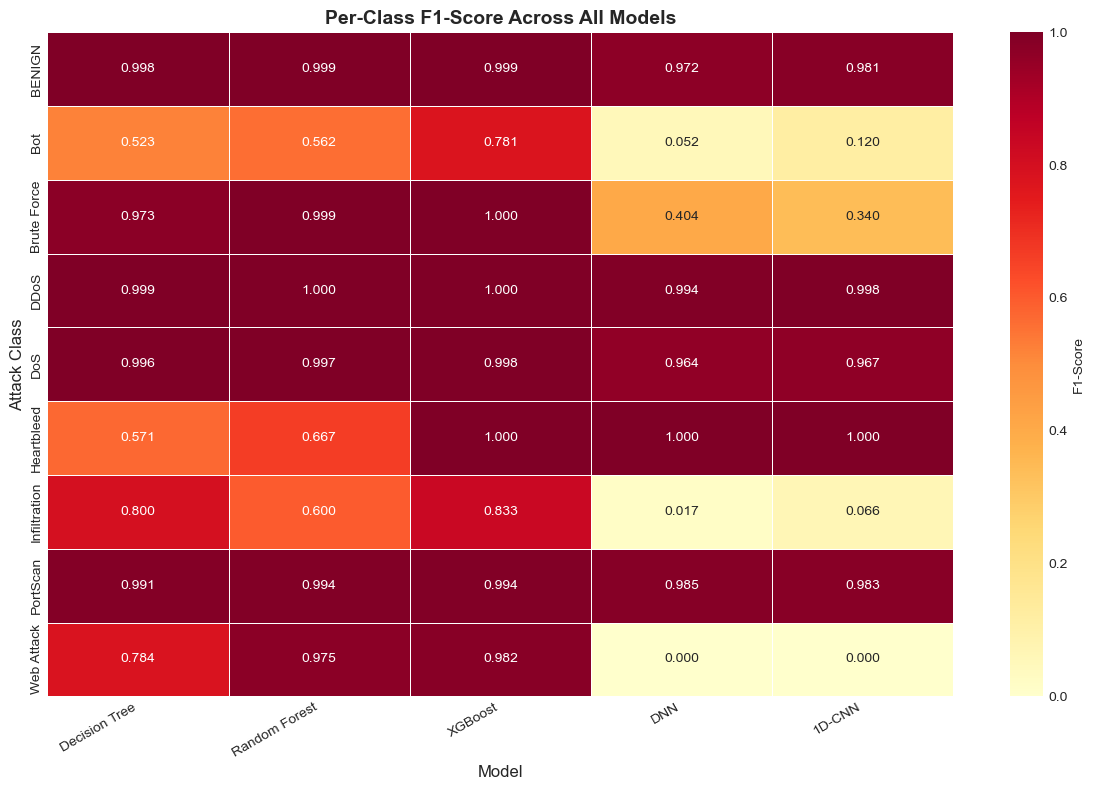

Saved: figures/per_class_f1.png


In [30]:
# ============================================================
# 6.2 Per-Class F1 Score Heatmap
# ============================================================
class_names = le.classes_
per_class_f1 = {}

for model_name in model_names:
    report = all_class_reports[model_name]
    per_class_f1[model_name] = [report.get(cls, {}).get('f1-score', 0) for cls in class_names]

f1_df = pd.DataFrame(per_class_f1, index=class_names)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='YlOrRd', vmin=0, vmax=1,
            ax=ax, linewidths=0.5, cbar_kws={'label': 'F1-Score'})
ax.set_title('Per-Class F1-Score Across All Models', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Attack Class', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/per_class_f1.png")

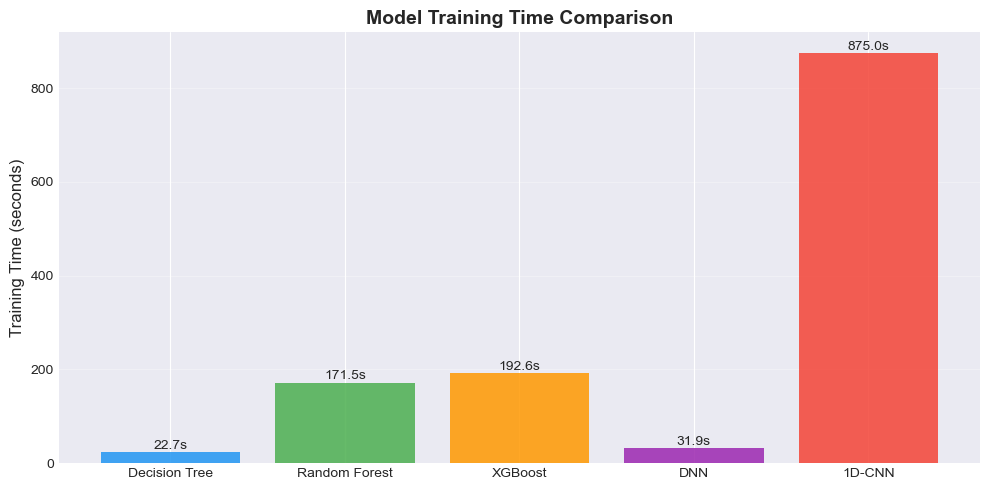

Saved: figures/training_time.png


In [31]:
# ============================================================
# 6.3 Training Time Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
train_times = [all_model_metrics[m].get('train_time', 0) for m in model_names]
bars = ax.bar(model_names, train_times, color=colors, alpha=0.85)
for bar, t in zip(bars, train_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{t:.1f}s', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Training Time (seconds)', fontsize=12)
ax.set_title('Model Training Time Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'training_time.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/training_time.png")

In [32]:
# ============================================================
# 6.4 Summary Table & Save All Metrics
# ============================================================
print("=" * 80)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 80)

summary_data = []
for model_name in model_names:
    m = all_model_metrics[model_name]
    summary_data.append({
        'Model': model_name,
        'Accuracy': f"{m.get('accuracy', 0):.4f}",
        'Precision': f"{m.get('precision_macro', 0):.4f}",
        'Recall': f"{m.get('recall_macro', 0):.4f}",
        'F1-Score': f"{m.get('f1_macro', 0):.4f}",
        'ROC-AUC': f"{m.get('roc_auc', 0):.4f}" if m.get('roc_auc') else 'N/A',
        'Train Time': f"{m.get('train_time', 0):.1f}s"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Determine best model
best_model = max(all_model_metrics.items(), key=lambda x: x[1].get('f1_macro', 0))
print(f"\nBest Model (by Macro F1-Score): {best_model[0]} ({best_model[1]['f1_macro']:.4f})")

# Save all metrics to JSON
metrics_to_save = {
    'model_metrics': {},
    'confusion_matrices': all_confusion_matrices,
    'class_reports': {},
    'best_model': best_model[0],
    'class_names': le.classes_.tolist(),
    'feature_names': top_features,
}

for model_name in model_names:
    m = all_model_metrics[model_name]
    metrics_to_save['model_metrics'][model_name] = {
        k: float(v) if isinstance(v, (float, np.floating)) else v
        for k, v in m.items() if k != 'cv_results'
    }
    # Save CV results separately (they contain strings)
    if 'cv_results' in m:
        metrics_to_save['model_metrics'][model_name]['cv_results'] = m['cv_results']
    
    # Clean class reports for JSON serialization
    report = all_class_reports[model_name]
    clean_report = {}
    for k, v in report.items():
        if isinstance(v, dict):
            clean_report[k] = {kk: float(vv) if isinstance(vv, (float, np.floating)) else vv 
                              for kk, vv in v.items()}
        else:
            clean_report[k] = float(v) if isinstance(v, (float, np.floating)) else v
    metrics_to_save['class_reports'][model_name] = clean_report

with open(os.path.join(MODELS_DIR, 'model_metrics.json'), 'w') as f:
    json.dump(metrics_to_save, f, indent=2)

print(f"\nAll metrics saved to models/model_metrics.json")
print("\nProject complete! Run 'streamlit run app.py' to launch the demo UI.")

FINAL MODEL COMPARISON SUMMARY
        Model Accuracy Precision Recall F1-Score ROC-AUC Train Time
Decision Tree   0.9966    0.7859 0.9829   0.8484  0.9916      22.7s
Random Forest   0.9978    0.9251 0.8789   0.8657  1.0000     171.5s
      XGBoost   0.9988    0.9553 0.9660   0.9541  1.0000     192.6s
          DNN   0.9531    0.5771 0.8471   0.5987  0.9928      31.9s
       1D-CNN   0.9678    0.5830 0.8430   0.6061  0.9827     875.0s

Best Model (by Macro F1-Score): XGBoost (0.9541)

All metrics saved to models/model_metrics.json

Project complete! Run 'streamlit run app.py' to launch the demo UI.
